# Event-TimeRAF Publication-Candidate Results

This notebook reads one manifest-backed final run. It does not train models or alter
predictions. It rejects mixed run identifiers and displays the diagnostics required before
any paper number is updated.


In [1]:
from pathlib import Path, PurePosixPath
import json
import shutil
import sys
import zipfile
import pandas as pd

RESULTS_ROOT_OVERRIDE = None
REQUIRE_FINAL_PUBLICATION_RUN = True
REQUIRE_PUBLICATION_TITLE_ALLOWED = True

def has_project_files(path):
    return (path / 'configs' / 'default.yaml').exists() and (path / 'src' / 'event_timeraf' / 'config.py').exists()

def reset_directory(path):
    path = path.resolve()
    kaggle_working = Path('/kaggle/working').resolve()
    if path.exists():
        if not path.is_relative_to(kaggle_working):
            raise RuntimeError(f'Refusing to refresh non-working directory: {path}')
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def locate_results_root():
    if RESULTS_ROOT_OVERRIDE is not None:
        override = Path(RESULTS_ROOT_OVERRIDE).resolve()
        if not has_project_files(override):
            raise FileNotFoundError(f'RESULTS_ROOT_OVERRIDE is missing src/event_timeraf/config.py: {override}')
        return override
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, Path('/kaggle/working/event_timeraf')]
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(path.parent.parent for path in kaggle_input.rglob('configs/default.yaml'))
    source = next((path for path in candidates if has_project_files(path)), None)
    if source is None and kaggle_input.exists():
        for archive in sorted(kaggle_input.rglob('*.zip')):
            with zipfile.ZipFile(archive) as bundle:
                members = [PurePosixPath(name) for name in bundle.namelist()]
                config_member = next((member for member in members if member.parts[-2:] == ('configs', 'default.yaml')), None)
                package_member = next((member for member in members if member.parts[-3:] == ('src', 'event_timeraf', 'config.py')), None)
                if config_member is None or package_member is None:
                    continue
                if any(member.is_absolute() or '..' in member.parts for member in members):
                    raise RuntimeError(f'Unsafe paths found in attached archive: {archive}')
                extracted = Path('/kaggle/working/event_timeraf_results_source')
                reset_directory(extracted)
                bundle.extractall(extracted)
                source = extracted.joinpath(*config_member.parts[:-2])
                break
    if source is None:
        raise FileNotFoundError('Set RESULTS_ROOT_OVERRIDE to a completed run directory.')
    if kaggle_input.exists() and source.is_relative_to(kaggle_input):
        writable = Path('/kaggle/working/event_timeraf_results')
        writable.mkdir(parents=True, exist_ok=True)
        for directory in ('configs', 'src', 'outputs'):
            if (source / directory).exists():
                target = writable / directory
                if target.exists():
                    shutil.rmtree(target)
                shutil.copytree(source / directory, target)
        return writable
    return source

PROJECT_ROOT = locate_results_root()
PACKAGE_ROOT = PROJECT_ROOT / 'src' / 'event_timeraf'
if not (PACKAGE_ROOT / 'config.py').exists():
    raise FileNotFoundError(f'Package file missing after setup: {PACKAGE_ROOT / "config.py"}')
for module_name in list(sys.modules):
    if module_name == 'event_timeraf' or module_name.startswith('event_timeraf.'):
        del sys.modules[module_name]
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print({'project_root': str(PROJECT_ROOT), 'package_root': str(PACKAGE_ROOT)})
from event_timeraf.config import load_config
from event_timeraf.plots import plot_horizon_metrics

cfg = load_config(PROJECT_ROOT / 'configs' / 'default.yaml', PROJECT_ROOT)
manifest = json.loads((cfg.paths.outputs / 'logs' / 'run_manifest.json').read_text(encoding='utf-8'))
audit = json.loads((cfg.paths.outputs / 'audit' / 'data_audit.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(cfg.paths.outputs / 'tables' / 'metrics.csv')
predictions = pd.read_parquet(cfg.paths.outputs / 'predictions' / 'predictions.parquet')
explanations = pd.read_parquet(cfg.paths.outputs / 'evidence' / 'explanations.parquet')
ablation = pd.read_csv(cfg.paths.outputs / 'tables' / 'ablation_results.csv')
subset_counts = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_counts.csv')
drift_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_period_results.csv')
event_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_period_results.csv')
stride_results = pd.read_csv(cfg.paths.outputs / 'tables' / 'kb_stride_sensitivity.csv')
stride_models = pd.read_csv(cfg.paths.outputs / 'tables' / 'kb_stride_model_sensitivity.csv')
event_weights = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_weight_sensitivity.csv')
event_composition = pd.read_csv(cfg.paths.outputs / 'tables' / 'event_candidate_composition.csv')
subset_statistics = pd.read_csv(cfg.paths.outputs / 'tables' / 'subset_target_statistics.csv')
drift_comparison = pd.read_csv(cfg.paths.outputs / 'tables' / 'drift_detector_comparison.csv')
group_permutation = pd.read_csv(cfg.paths.outputs / 'tables' / 'validation_group_permutation.csv')
run_ids = (
    set(metrics['run_id']) | set(predictions['run_id']) | set(explanations['run_id'])
    | set(ablation['run_id']) | set(subset_counts['run_id'])
    | set(drift_results['run_id']) | set(event_results['run_id'])
    | set(stride_results['run_id']) | set(stride_models['run_id'])
    | set(event_weights['run_id']) | set(event_composition['run_id'])
    | set(subset_statistics['run_id']) | set(drift_comparison['run_id'])
    | set(group_permutation['run_id'])
)
if run_ids != {manifest['run_id']}:
    raise RuntimeError(f'Mixed or stale run artifacts detected: {sorted(run_ids)} vs manifest {manifest["run_id"]}')
availability_modes = (
    set(metrics['event_availability_mode']) | set(predictions['event_availability_mode'])
    | set(explanations['event_availability_mode'])
)
if availability_modes != {manifest['run_options']['event_availability_mode']}:
    raise RuntimeError(f'Event-availability metadata mismatch: {sorted(availability_modes)}')
run_options = manifest['run_options']
if REQUIRE_FINAL_PUBLICATION_RUN:
    required_true_options = {
        'require_events': run_options.get('require_events'),
        'final_experiment': run_options.get('final_experiment'),
        'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
        'run_tsf_model': run_options.get('run_tsf_model'),
        'stride_model_sweep_completed': run_options.get('stride_model_sweep_completed'),
    }
    failed = [name for name, value in required_true_options.items() if value is not True]
    if failed:
        raise RuntimeError(f'Not a final-publication run; failed manifest options: {failed}')
    if not audit.get('core_ready') or not audit.get('event_ready'):
        raise RuntimeError('Final run failed data-readiness gates in data_audit.json')
if run_options.get('primary_kb_stride_hours') != 24:
    raise RuntimeError('Publication-candidate run must use the primary 24-hour knowledge-base stride.')
if run_options.get('drift_score_mode') != 'two_sided':
    raise RuntimeError('Publication-candidate run must use two-sided drift scoring.')
if run_options.get('bootstrap_block_hours', 0) < 168:
    raise RuntimeError('Publication-candidate inference must use blocks of at least 168 origins.')
if REQUIRE_PUBLICATION_TITLE_ALLOWED and not run_options.get('publication_title_allowed'):
    raise RuntimeError('Frozen-TSFM publication gate did not complete; do not use foundation-model title/claims.')
print({
    'run_id': manifest['run_id'],
    'event_availability_mode': run_options['event_availability_mode'],
    'final_experiment': run_options.get('final_experiment'),
    'run_tsf_model': run_options.get('run_tsf_model'),
        'stride_model_sweep_completed': run_options.get('stride_model_sweep_completed'),
    'retrieval_evidence_reviewed': run_options.get('retrieval_evidence_reviewed'),
    'publication_title_allowed': run_options.get('publication_title_allowed'),
})


{'project_root': '/kaggle/working/event_timeraf_results', 'package_root': '/kaggle/working/event_timeraf_results/src/event_timeraf'}
{'run_id': '20260816T134423330280Z', 'event_availability_mode': 'retrospective_event_start', 'final_experiment': True, 'run_tsf_model': True, 'stride_model_sweep_completed': True, 'retrieval_evidence_reviewed': True, 'publication_title_allowed': True}


,run_id,model,subset,event_availability_mode,n_origins,n_points,horizon,mse,mae,rmse,mape,smape,r2
3042,20260816T134423330280Z,A01_xgb_random_retrieval,all,retrospective_event_start,7199,172776,overall,26.046146,3.116235,5.103542,184.563824,31.719907,0.382315
2106,20260816T134423330280Z,M04_xgb_context,all,retrospective_event_start,7199,172776,overall,26.184621,3.125194,5.117091,180.656206,31.787274,0.379031
4212,20260816T134423330280Z,M12_validation_drift_router,all,retrospective_event_start,7199,172776,overall,26.374850,3.122542,5.135645,172.964255,31.789807,0.374520
2574,20260816T134423330280Z,M07_xgb_cosine,all,retrospective_event_start,7199,172776,overall,26.430975,3.128779,5.141106,182.611566,31.784902,0.373189
2808,20260816T134423330280Z,M08_event_timeraf_no_drift,all,retrospective_event_start,7199,172776,overall,26.447720,3.128732,5.142735,182.920861,31.807399,0.372791
3510,20260816T134423330280Z,A00_full_without_events,all,retrospective_event_start,7199,172776,overall,26.498991,3.134861,5.147717,183.663468,31.858121,0.371576
3276,20260816T134423330280Z,M09_event_timeraf_full,all,retrospective_event_start,7199,172776,overall,26.522839,3.138093,5.150033,182.463348,31.898200,0.371010
2340,20260816T134423330280Z,C01_ridge_context,all,retrospective_event_start,7199,172776,overall,28.430699,3.223981,5.332045,161.512088,32.776804,0.325765
3978,20260816T134423330280Z,M11_chronos_event_retrieval,all,retrospective_event_start,7199,172776,overall,28.564806,3.202057,5.344605,137.824131,32.744651,0.322585
3744,20260816T134423330280Z,M10_frozen_chronos,all,retrospective_event_start,7199,172776,overall,28.941491,3.204711,5.379730,120.882436,32.868238,0.313652


,run_id,subset,n_origins,eligible_for_metrics
0,20260816T134423330280Z,event,532,True
1,20260816T134423330280Z,non_event,6667,True
2,20260816T134423330280Z,recent_event,637,True
3,20260816T134423330280Z,active_event,293,True
4,20260816T134423330280Z,event_context,636,True
5,20260816T134423330280Z,non_event_context,6563,True
6,20260816T134423330280Z,drift,531,True
7,20260816T134423330280Z,non_drift,6668,True


,run_id,subset,n_origins,target_mean,target_variance,climatology_mse,M04_skill_vs_climatology,M09_skill_vs_climatology
0,20260816T134423330280Z,all,7199,10.041140,42.167339,35.996059,0.272570,0.263174
1,20260816T134423330280Z,event,532,7.940143,22.635916,22.366210,0.577446,0.534630
2,20260816T134423330280Z,non_event,6667,10.208790,43.345539,37.083667,0.257897,0.250109
3,20260816T134423330280Z,recent_event,637,7.333421,18.333677,19.730907,0.578260,0.560992
4,20260816T134423330280Z,active_event,293,10.572946,15.920782,16.085858,0.415906,0.341079
5,20260816T134423330280Z,event_context,636,7.310594,18.355503,19.871961,0.582274,0.564888
6,20260816T134423330280Z,non_event_context,6563,10.305749,43.682327,37.558596,0.256690,0.247704
7,20260816T134423330280Z,drift,531,9.597904,70.005699,50.618280,0.472525,0.419846
8,20260816T134423330280Z,non_drift,6668,10.076435,39.933571,34.831632,0.249430,0.245043


,run_id,comparison,metric,difference,ci_low,ci_high
0,20260816T134423330280Z,M04_minus_M03_weather_calendar,mse,-3.764322,-7.172501,-1.725508
1,20260816T134423330280Z,M04_minus_M03_weather_calendar,mae,-0.243000,-0.342466,-0.165095
2,20260816T134423330280Z,M07_minus_M04_cosine_retrieval,mse,0.246351,-0.201360,0.856355
3,20260816T134423330280Z,M07_minus_M04_cosine_retrieval,mae,0.003584,-0.013776,0.022662
4,20260816T134423330280Z,M08_minus_M07_event_conditioning,mse,0.016747,-0.171729,0.214668
5,20260816T134423330280Z,M08_minus_M07_event_conditioning,mae,-0.000047,-0.014621,0.018844
6,20260816T134423330280Z,M09_minus_M08_drift_features,mse,0.075121,-0.044254,0.233465
7,20260816T134423330280Z,M09_minus_M08_drift_features,mae,0.009361,0.000584,0.019558
8,20260816T134423330280Z,M09_minus_A00_events,mse,0.023849,-0.142537,0.206201
9,20260816T134423330280Z,M09_minus_A00_events,mae,0.003232,-0.010299,0.018772


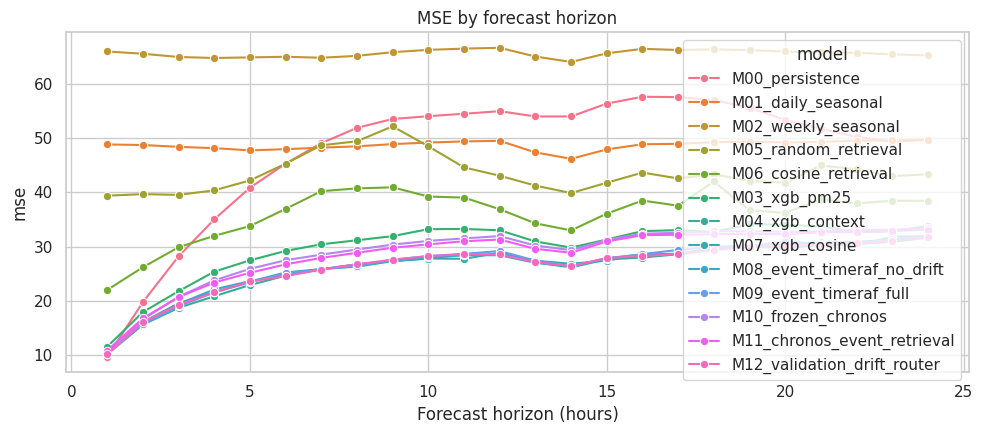

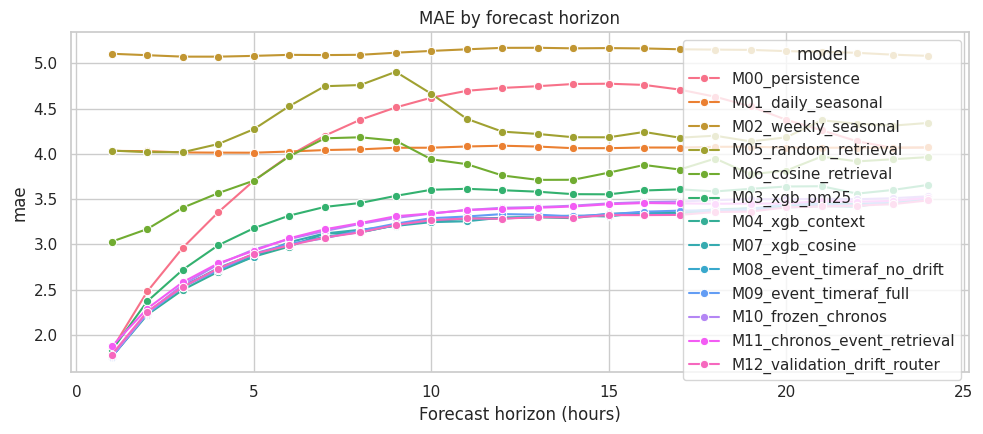

In [2]:
overall = metrics.loc[
    (metrics['horizon'].astype(str) == 'overall') & (metrics['subset'] == 'all')
].sort_values('mse')
display(overall)
primary_metrics = metrics.loc[metrics['model'].str.startswith('M')]
plot_horizon_metrics(primary_metrics, 'mse')
plot_horizon_metrics(primary_metrics, 'mae')
display(subset_counts)
display(subset_statistics)
display(ablation)


In [3]:
display(stride_results.sort_values(['method', 'stride_hours']))
display(stride_models.sort_values(['model', 'stride_hours']))
display(event_weights.sort_values(['subset', 'event_weight']))
display(event_composition)
display(group_permutation.sort_values('mse_increase', ascending=False))
display(drift_comparison)
display(drift_results)
display(event_results)
display(explanations.sort_values('drift_score', ascending=False).head(10))


,run_id,stride_hours,method,candidate_count,runtime_seconds,minimum_eligible_candidates,mse,mae,rmse,mape,smape,r2
7,20260816T134423330280Z,6,cosine,5661,53.484699,5661,33.619180,3.622686,5.798205,200.076246,36.373121,0.202720
4,20260816T134423330280Z,24,cosine,1358,0.000009,1358,36.091946,3.799744,6.007657,212.577639,38.335102,0.144078
1,20260816T134423330280Z,192,cosine,171,37.718614,171,38.114133,3.881514,6.173664,221.503586,38.682839,0.096122
8,20260816T134423330280Z,6,event_conditioned,5661,53.484699,5661,33.509194,3.622842,5.788713,207.342823,36.399252,0.205328
5,20260816T134423330280Z,24,event_conditioned,1358,0.000009,1358,37.498878,3.882307,6.123633,196.208992,38.966495,0.110713
2,20260816T134423330280Z,192,event_conditioned,171,37.718614,171,38.091624,3.934240,6.171841,214.827059,39.384115,0.096656
6,20260816T134423330280Z,6,random,5661,53.484699,5661,41.823616,4.227201,6.467118,314.873829,42.006133,0.008151
3,20260816T134423330280Z,24,random,1358,0.000009,1358,43.544123,4.315619,6.598797,287.454834,42.897782,-0.032650
0,20260816T134423330280Z,192,random,171,37.718614,171,42.759712,4.261582,6.539091,299.841391,42.674308,-0.014048


,run_id,stride_hours,model,mse,mae,rmse,mape,smape,r2
6,20260816T134423330280Z,6,M07_xgb_cosine,26.335878,3.123458,5.131849,178.576787,31.734117,0.375444
3,20260816T134423330280Z,24,M07_xgb_cosine,26.430975,3.128779,5.141106,182.611566,31.784902,0.373189
0,20260816T134423330280Z,192,M07_xgb_cosine,26.501121,3.132952,5.147924,190.523715,31.844737,0.371525
7,20260816T134423330280Z,6,M08_event_timeraf_no_drift,26.547633,3.116921,5.152440,184.308448,31.721151,0.370422
4,20260816T134423330280Z,24,M08_event_timeraf_no_drift,26.447720,3.128732,5.142735,182.920861,31.807399,0.372791
1,20260816T134423330280Z,192,M08_event_timeraf_no_drift,26.705107,3.149447,5.167698,183.762475,31.935206,0.366687
8,20260816T134423330280Z,6,M09_event_timeraf_full,26.615068,3.124259,5.158979,183.407369,31.777681,0.368823
5,20260816T134423330280Z,24,M09_event_timeraf_full,26.522839,3.138093,5.150033,182.463348,31.898200,0.371010
2,20260816T134423330280Z,192,M09_event_timeraf_full,26.828688,3.157087,5.179642,183.181468,32.016517,0.363757


,run_id,event_weight,subset,n_origins,mse,mae,rmse,mape,smape,r2,selected_candidate_changed_fraction_vs_weight_0
0,20260816T134423330280Z,0.0,all,7199,37.444958,3.880525,6.119229,198.755288,38.964044,0.111992,0.000000
3,20260816T134423330280Z,0.2,all,7199,37.498878,3.882307,6.123633,196.208992,38.966495,0.110713,0.083223
6,20260816T134423330280Z,0.5,all,7199,37.617935,3.893722,6.133346,197.110429,39.096868,0.107889,0.086366
9,20260816T134423330280Z,0.8,all,7199,37.667258,3.898601,6.137366,196.146966,39.152534,0.106720,0.086766
12,20260816T134423330280Z,1.0,all,7199,37.887335,3.918446,6.155269,199.380816,39.362128,0.101501,0.087634
1,20260816T134423330280Z,0.0,event_context,636,16.564844,3.176492,4.069993,191.818806,48.440915,0.097554,NaN
4,20260816T134423330280Z,0.2,event_context,636,17.175169,3.196664,4.144294,162.996823,48.468664,0.064304,NaN
7,20260816T134423330280Z,0.5,event_context,636,18.522792,3.325875,4.303811,173.200345,49.944375,-0.009114,NaN
10,20260816T134423330280Z,0.8,event_context,636,19.081096,3.381102,4.368191,162.294730,50.574473,-0.039530,NaN
13,20260816T134423330280Z,1.0,event_context,636,21.572186,3.605729,4.644587,198.899275,52.946911,-0.175244,NaN


,run_id,event_weight,event_context_queries,conditioned_queries,selected_candidate_event_fraction,event_score_zero_fraction
0,20260816T134423330280Z,0.0,636,636,0.173809,0.247152
1,20260816T134423330280Z,0.2,636,636,0.173809,0.240120
2,20260816T134423330280Z,0.5,636,636,0.173809,0.239634
3,20260816T134423330280Z,0.8,636,636,0.173809,0.239599
4,20260816T134423330280Z,1.0,636,636,0.173809,0.239599


,run_id,feature_group,validation_mse,mse_increase
0,20260816T134423330280Z,pm25,32.785409,14.317528
2,20260816T134423330280Z,calendar,20.456226,1.988344
1,20260816T134423330280Z,weather,20.238127,1.770245
3,20260816T134423330280Z,event,19.216206,0.748324
4,20260816T134423330280Z,retrieval,19.183616,0.715734


,run_id,detector,threshold,flagged_origins,flag_jaccard
0,20260816T134423330280Z,Event-TimeRAF composite,0.235177,531,0.118194
1,20260816T134423330280Z,KS two-sample,0.411500,1153,0.118194


,run_id,model,drift_flag,n_origins,n_points,eligible_for_metrics,mse,mae,skill_vs_climatology,event_availability_mode
0,20260816T134423330280Z,C00_hour_month_climatology,False,6668,160032,True,34.831632,3.900026,0.000000,retrospective_event_start
1,20260816T134423330280Z,C02_calendar_retrieval,False,6668,160032,True,42.172938,4.231815,-0.210765,retrospective_event_start
2,20260816T134423330280Z,C03_event_conditioned_retrieval,False,6668,160032,True,36.136401,3.793996,-0.037459,retrospective_event_start
3,20260816T134423330280Z,M00_persistence,False,6668,160032,True,42.924495,4.069724,-0.232342,retrospective_event_start
4,20260816T134423330280Z,M01_daily_seasonal,False,6668,160032,True,39.383910,3.944630,-0.130694,retrospective_event_start
5,20260816T134423330280Z,M02_weekly_seasonal,False,6668,160032,True,59.537845,4.975045,-0.709304,retrospective_event_start
6,20260816T134423330280Z,M05_random_retrieval,False,6668,160032,True,41.917358,4.212605,-0.203428,retrospective_event_start
7,20260816T134423330280Z,M06_cosine_retrieval,False,6668,160032,True,35.107658,3.739841,-0.007925,retrospective_event_start
8,20260816T134423330280Z,M03_xgb_pm25,False,6668,160032,True,29.192370,3.294932,0.161901,retrospective_event_start
9,20260816T134423330280Z,M04_xgb_context,False,6668,160032,True,26.143590,3.095859,0.249430,retrospective_event_start


,run_id,model,target_event_flag,n_origins,n_points,eligible_for_metrics,mse,mae,skill_vs_climatology,event_availability_mode
0,20260816T134423330280Z,C00_hour_month_climatology,False,6667,160008,True,37.083667,4.003097,0.000000,retrospective_event_start
1,20260816T134423330280Z,C02_calendar_retrieval,False,6667,160008,True,45.256985,4.367656,-0.220402,retrospective_event_start
2,20260816T134423330280Z,C03_event_conditioned_retrieval,False,6667,160008,True,39.125346,3.932029,-0.055056,retrospective_event_start
3,20260816T134423330280Z,M00_persistence,False,6667,160008,True,50.534917,4.260030,-0.362727,retrospective_event_start
4,20260816T134423330280Z,M01_daily_seasonal,False,6667,160008,True,51.524399,4.158086,-0.389409,retrospective_event_start
5,20260816T134423330280Z,M02_weekly_seasonal,False,6667,160008,True,67.917341,5.138841,-0.831462,retrospective_event_start
6,20260816T134423330280Z,M05_random_retrieval,False,6667,160008,True,45.186786,4.353221,-0.218509,retrospective_event_start
7,20260816T134423330280Z,M06_cosine_retrieval,False,6667,160008,True,37.881730,3.869234,-0.021521,retrospective_event_start
8,20260816T134423330280Z,M03_xgb_pm25,False,6667,160008,True,31.424343,3.422770,0.152610,retrospective_event_start
9,20260816T134423330280Z,M04_xgb_context,False,6667,160008,True,27.519902,3.179047,0.257897,retrospective_event_start


,run_id,window_id,origin_time,explanation,retrieved_evidence_ids,event_evidence_ids,top_feature_effects,drift_components,retrieval_spread,validation_residual_rmse,uncertainty_proxy,drift_score,drift_flag,event_availability_mode
1014,20260816T134423330280Z,w_0045838,2024-03-24 22:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0036368"", ""w_0035168"", ""w_0035192""]","[""storm_1207125""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.2976033091545105, ""variance_s...",4.069075,4.320162,5.934743,0.551295,True,retrospective_event_start
1013,20260816T134423330280Z,w_0045837,2024-03-24 21:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0036368"", ""w_0035168"", ""w_0025424""]",[],"[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.2976033091545105, ""variance_s...",3.728305,4.320162,5.706493,0.549450,True,retrospective_event_start
1015,20260816T134423330280Z,w_0045839,2024-03-24 23:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0036368"", ""w_0035168"", ""w_0023648""]","[""storm_1207125""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.3093613386154175, ""variance_s...",4.024503,4.320162,5.904272,0.538745,True,retrospective_event_start
295,20260816T134423330280Z,w_0045040,2024-02-20 16:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033800"", ""w_0036368"", ""w_0008000""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.37620049715042114, ""variance_...",3.527549,4.320162,5.577401,0.516813,True,retrospective_event_start
1016,20260816T134423330280Z,w_0045840,2024-03-25 00:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0035168"", ""w_0036368"", ""w_0023648""]","[""storm_1207126"", ""storm_1207125""]","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.31260302662849426, ""variance_...",4.186325,4.320162,6.015739,0.500441,True,retrospective_event_start
300,20260816T134423330280Z,w_0045045,2024-02-20 21:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0023648"", ""w_0033800"", ""w_0008000""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.35092633962631226, ""variance_...",4.406502,4.320162,6.170985,0.486896,True,retrospective_event_start
296,20260816T134423330280Z,w_0045041,2024-02-20 17:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033800"", ""w_0008000"", ""w_0018176""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3683984577655792, ""variance_s...",3.317623,4.320162,5.447057,0.478383,True,retrospective_event_start
298,20260816T134423330280Z,w_0045043,2024-02-20 19:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033800"", ""w_0008000"", ""w_0025904""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3531515300273895, ""variance_s...",3.336522,4.320162,5.458588,0.476735,True,retrospective_event_start
288,20260816T134423330280Z,w_0045033,2024-02-20 09:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0033800"", ""w_0017480"", ""w_0025904""]","[""storm_1187872"", ""storm_1187875"", ""storm_1187...","[{""feature"": ""pm25_roll_mean_24h"", ""mean_contr...","{""mean_shift"": 0.3866397738456726, ""variance_s...",3.073052,4.320162,5.301646,0.476125,True,retrospective_event_start
299,20260816T134423330280Z,w_0045044,2024-02-20 20:00:00+00:00,The mean 24-hour forecast is expected to incre...,"[""w_0008000"", ""w_0033800"", ""w_0025904""]","[""storm_1187887"", ""storm_1187872"", ""storm_1187...","[{""feature"": ""pm25_current"", ""mean_contributio...","{""mean_shift"": 0.3472176492214203, ""variance_s...",4.150